**IMPORTING LIBRARIES**

In [154]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import joblib
from sklearn.utils.class_weight import compute_sample_weight

**EXPLORATORY DATA ANALYSIS**

In [155]:
df = pd.read_csv("UNSW_NB15_training-set.csv", encoding='latin-1')
df.head()

,ï»¿id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [156]:
# Fix weird BOM issue (ï»¿id)
df.columns = df.columns.str.replace('ï»¿', '')

In [157]:
print("Shape:", df.shape)

Shape: (82332, 45)


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [159]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.00000,8.233200e+04,8.233200e+04,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,4.753692,6.308556,755.394301,121.701284,6.363075e+03,535.180430,133.45908,1.084642e+09,1.073465e+09,128.28662,0.055925,0.029256,0.026669,139.528604,116.275069,0.094277,1.595372e+03,9.546604,1.369273,5.744923,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,64.649620,55.708021,6182.615732,1292.378499,5.672402e+04,3635.305383,127.35700,1.390860e+09,1.381996e+09,127.49137,0.116022,0.070854,0.055094,208.472063,244.600271,0.542922,3.806697e+04,11.090289,1.067188,8.418112,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,1.000000,0.000000,0.557929,0.010000,1.762392e+01,0.000000,255.00000,2.788886e+07,2.856975e+07,255.00000,0.000551,0.000441,0.000080,65.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,3.000000,2.000000,63.409444,63.136369,3.219332e+03,128.459914,255.00000,2.171310e+09,2.144205e+09,255.00000,0.105541,0.052596,0.048816,100.000000,87.000000,0.000000,0.000000e+00,11.000000,2.000000,6.000000,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,2.082111e+07,5319.000000,5507.000000,60009.992000,57739.240000,1.483831e+06,463199.240100,255.00000,4.294950e+09,4.294881e+09,255.00000,3.821465,3.226788,2.928778,1504.000000,1500.000000,131.000000,5.242880e+06,63.000000,6.000000,59.000000,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [160]:
df.describe(include='all')

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,82332.000000,82332.000000,82332,82332,82332,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.00000,8.233200e+04,8.233200e+04,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332,82332.000000
unique,NaN,NaN,131,13,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,43095,47153,39339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37000,NaN
mean,41166.500000,1.006756,NaN,NaN,NaN,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,4.753692,6.308556,755.394301,121.701284,6.363075e+03,535.180430,133.45908,1.084642e+09,1.073465e+09,128.28662,0.055925,0.029256,0.026669,139.528604,116.275069,0.094277,1.595372e+03,9.546604,1.369273,5.744923,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,NaN,0.550600
std,23767.345519,4.710444,NaN,NaN,NaN,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,64.649620,55.708021,6182.615732,1292.378499,5.672402e+04,3635.305383,127.35700,1.390860e+09,1.381996e+09,127.49137,0.116022,0.070854,0.055094,208.472063,244.600271,0.542922,3.806697e+04,11.090289,1.067188,8.418112,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,NaN,0.497436
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,20583.750000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,NaN,0.000000
50%,41166.500000,0.014138,NaN,NaN,NaN,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,1.000000,0.000000,0.557929,0.010000,1.762392e+01,0.000000,255.00000,2.788886e+07,2.856975e+07,255.00000,0.000551,0.000441,0.000080,65.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,NaN,1.000000
75%,61749.250000,0.719360,NaN,NaN,NaN,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,3.000000,2.000000,63.409444,63.136369,3.219332e+03,128.459914,255.00000,2.171310e+09,2.144205e+09,255.00000,0.105541,0.052596,0.048816,100.000000,87.000000,0.

In [161]:
df.isnull().sum()

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [162]:
df.dtypes

,0
id,int64
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64


In [163]:
# Remove unwanted columns (IMPORTANT)
df.drop(['id'], axis=1, inplace=True)

In [164]:
df.shape

(82332, 44)

**NORMAL VS ATTACK DISTRIBUTION**

In [165]:
# Count values [reset_index() converts series into data frame]
counts = df['label'].value_counts().reset_index()
counts.columns = ['Label', 'Count']

# Map labels for readability
counts['Label'] = counts['Label'].map({0: 'Normal', 1: 'Attack'})

# Plot
fig = px.bar(
    counts,
    x='Label',
    y='Count',
    text='Count',
    title="Normal vs Attack Distribution",
    color='Label'
)

# Show numbers on top
fig.update_traces(textposition='outside')

# Clean layout
fig.update_layout(
    xaxis_title="Traffic Type",
    yaxis_title="Count",
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()

**ATTACK CATEGORY DISTRIBUTION**

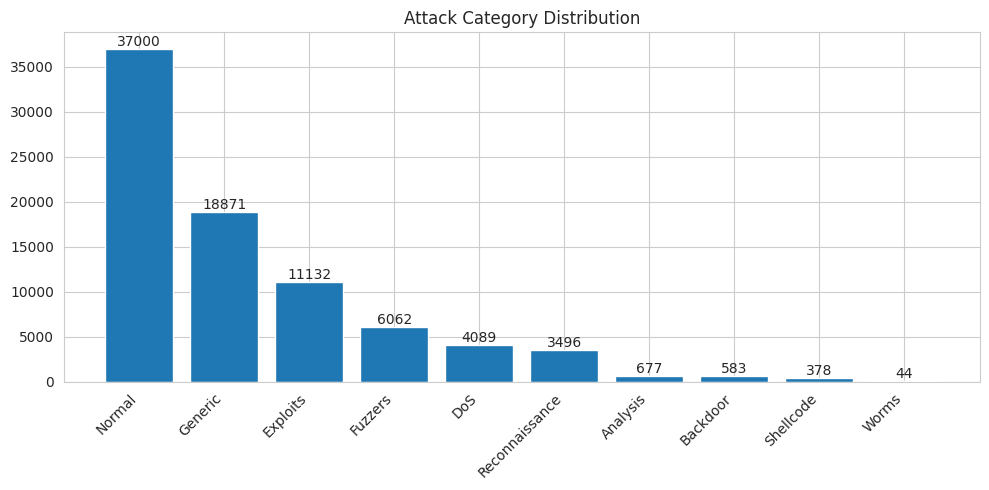

In [166]:


counts = df['attack_cat'].value_counts()

plt.figure(figsize=(10,5))
bars = plt.bar(counts.index, counts.values)

plt.title("Attack Category Distribution")
plt.xticks(rotation=45, ha='right')

# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

**TOP 10 PROTOCOLS**

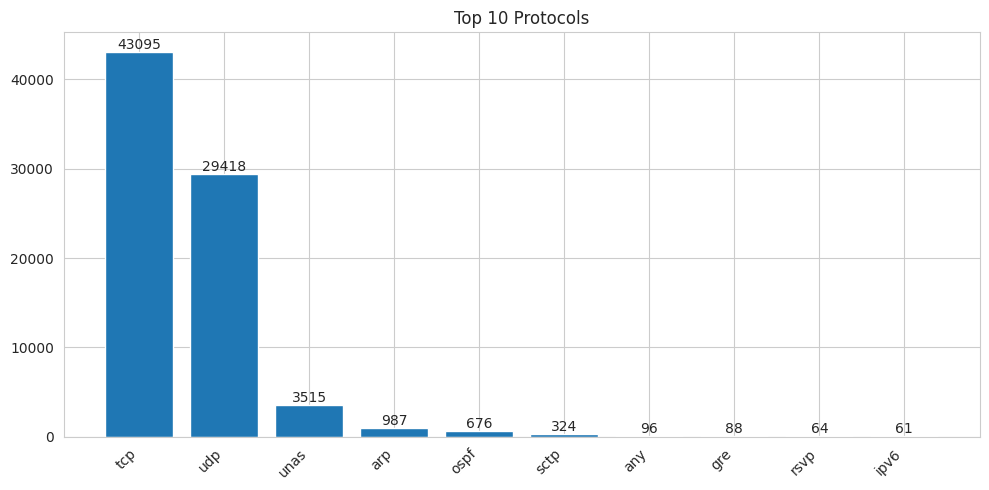

In [167]:


counts = df['proto'].value_counts().head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(counts.index, counts.values)

plt.title("Top 10 Protocols")
plt.xticks(rotation=45, ha='right')

# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

**CORRELATION HEATMAP**

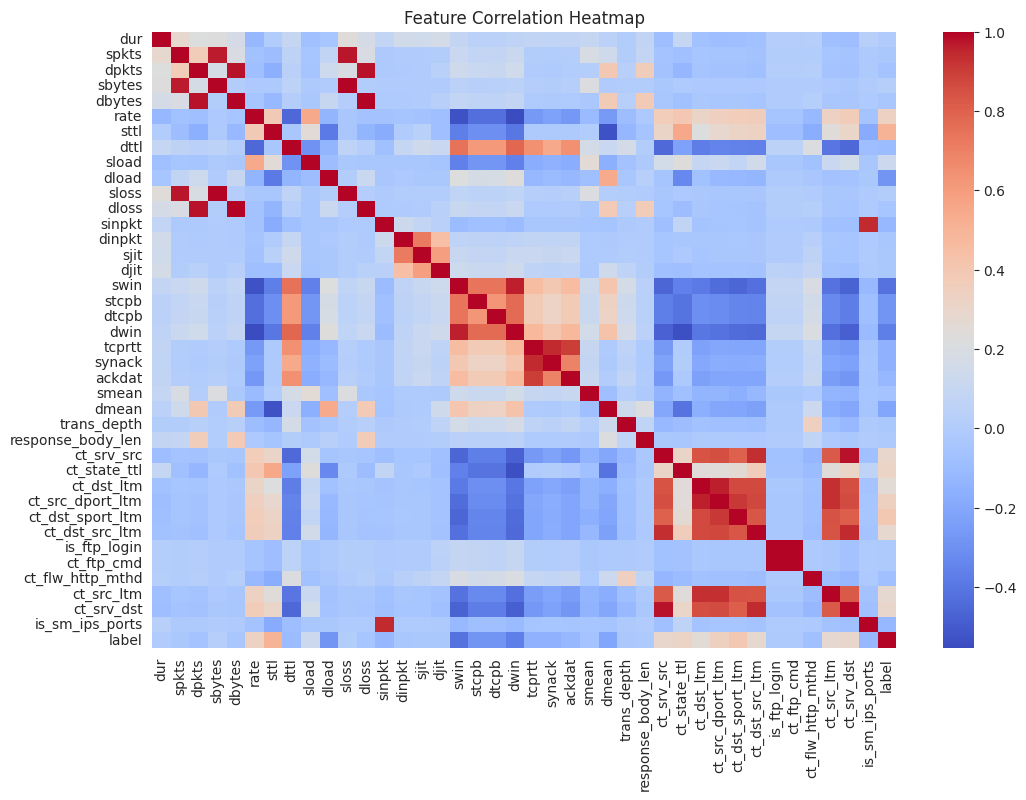

In [168]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**TOP 10 FEATURE CORRELATION HEATMAP**

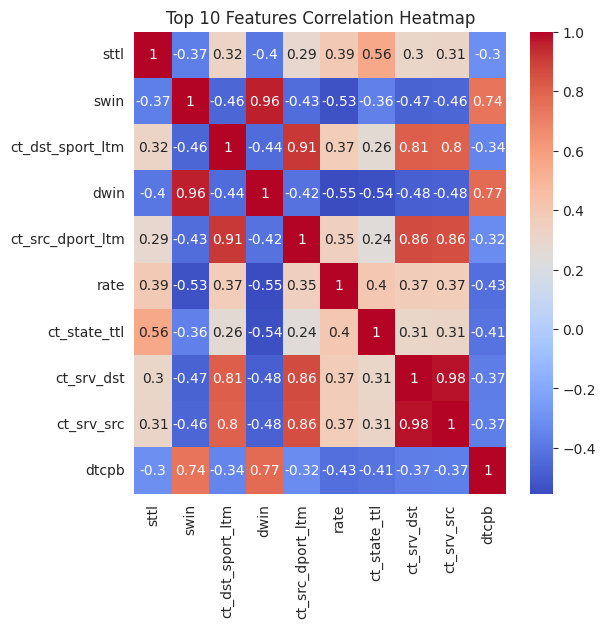

In [169]:
# Correlation with target
corr = df.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)

# Select top 10 (excluding label itself)
top10 = corr[1:11]

plt.figure(figsize=(6,6))
sns.heatmap(df[top10.index].corr(), annot=True, cmap='coolwarm')

plt.title("Top 10 Features Correlation Heatmap")
plt.show()

In [170]:
df_plot = df.copy()
df_plot['Label'] = df_plot['label'].map({0: 'Normal', 1: 'Attack'})

fig = px.scatter(
    df_plot,
    x='spkts',
    y='dpkts',
    facet_col='Label',
    color='Label',   # required for custom colors
    color_discrete_map={
        'Normal': 'blue',
        'Attack': 'red'   # force Attack to red
    },
    title="Packet Distribution (Separated)",
    opacity=0.7
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title="Source Packets",
    yaxis_title="Destination Packets"
)

fig.show()

**“Attack traffic deviates from normal packet patterns, appearing as outliers, which helps the model distinguish malicious behavior.”**

In [171]:
fig = px.histogram(
    df_plot,
    x='dur',
    color='Label',
    nbins=50,
    facet_col='Label',   # splits into two graphs based on values of label
    title="Flow Duration by Class"
)

fig.update_layout(template='plotly_dark')
fig.show()

**“The distribution is highly skewed, with most connections being short-lived, while long-duration flows may represent persistent or malicious activity.”**

In [172]:
df_plot = df.copy()
df_plot['Label'] = df_plot['label'].map({0: 'Normal', 1: 'Attack'})

fig = px.scatter(
    df_plot,
    x='sbytes',
    y='dbytes',
    color='Label',                 # enables coloring
    facet_col='Label',             # separates plots
    color_discrete_map={
        'Normal': 'blue',
        'Attack': 'red'            # orce colors
    },
    title="Bytes Distribution (Separated)",
    opacity=0.7
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title="Source Bytes",
    yaxis_title="Destination Bytes"
)

fig.show()

**LABEL ENCODING**

In [173]:
encoders = {}

for col in df.select_dtypes(include="object").columns:
    if col not in ['attack_cat']:
        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

        encoders[col] = le

**TARGET AND INDEPENDANT VARIABLES**

In [174]:
X = df.drop(['label', 'attack_cat'], axis=1)
y = df['label']

**TRAINING AND TESTING**

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**SCALING**

In [176]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**MODEL BUILDING FOR BINARY CLASSIFICATION**

In [177]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,#Uses 80% of data for each tree
    colsample_bytree=0.8,#Uses 80% of features for each tree
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

**PERFORMANCE**

In [178]:
y_pred = model.predict(X_test)

print("\n=== BINARY RESULTS ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


=== BINARY RESULTS ===
Accuracy: 97.85 %
F1 Score: 0.9803

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7400
           1       0.99      0.97      0.98      9067

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



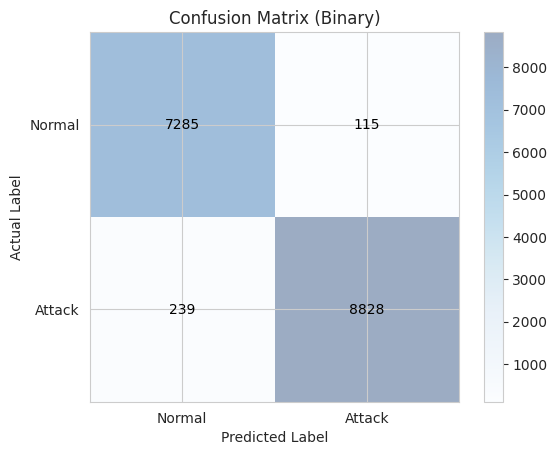

In [179]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()

# VERY LIGHT color
plt.imshow(cm, cmap='Blues', alpha=0.4)

plt.title("Confusion Matrix (Binary)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add numbers with dynamic color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "black"  # always visible on light background
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color)

plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])

plt.colorbar()
plt.show()

**FEATURE IMPORTANCE**

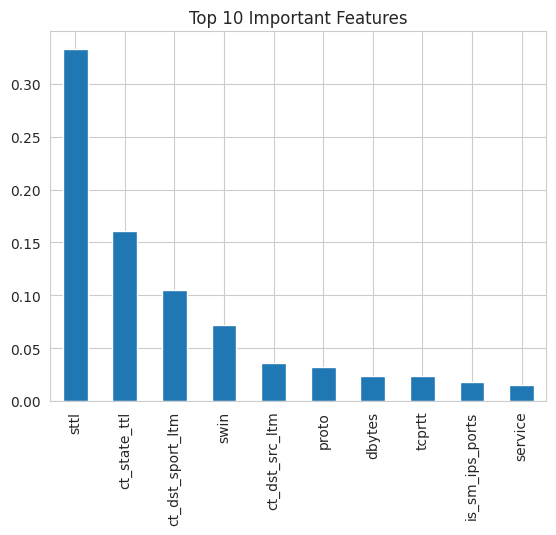

In [180]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

**LABEL ENCODING FOR IDENTYFYING TYPE OF ATTACK AND BUILDING MODEL**

In [181]:
le_attack = LabelEncoder()
df['attack_cat'] = le_attack.fit_transform(df['attack_cat'])

In [182]:
X_multi = df.drop(['label', 'attack_cat'], axis=1)
y_multi = df['attack_cat']

In [183]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)



multiclass_scaler = StandardScaler()

X_train_m = multiclass_scaler.fit_transform(
    X_train_m
)

X_test_m = multiclass_scaler.transform(
    X_test_m
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_m
)

# Model
model_multi = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    eval_metric="mlogloss",
    random_state=42
)

# Training
model_multi.fit(
    X_train_m,
    y_train_m,
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [184]:
# Predictions
y_pred_m = model_multi.predict(
    X_test_m
)

print("\n=== MULTI-CLASS RESULTS ===")

print("\n=== MULTI-CLASS RESULTS (SMOTE + TOMEK) ===")

accuracy_multi = accuracy_score(
    y_test_m,
    y_pred_m
)

weighted_f1_multi = f1_score(
    y_test_m,
    y_pred_m,
    average="weighted"
)

macro_f1_multi = f1_score(
    y_test_m,
    y_pred_m,
    average="macro"
)

print(
    "Accuracy:",
    round(accuracy_multi * 100, 2),
    "%"
)

print(
    "Weighted F1:",
    round(weighted_f1_multi, 4)
)

print(
    "Macro F1:",
    round(macro_f1_multi, 4)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_m,
        y_pred_m,
        zero_division=0
    )
)


=== MULTI-CLASS RESULTS ===

=== MULTI-CLASS RESULTS (SMOTE + TOMEK) ===
Accuracy: 86.1 %
Weighted F1: 0.8762
Macro F1: 0.6219

Classification Report:

              precision    recall  f1-score   support

           0       0.04      0.08      0.06       135
           1       0.06      0.30      0.10       117
           2       0.44      0.59      0.51       818
           3       0.84      0.62      0.72      2227
           4       0.76      0.72      0.74      1212
           5       1.00      0.98      0.99      3774
           6       0.98      0.95      0.97      7400
           7       0.85      0.82      0.84       699
           8       0.35      0.83      0.49        76
           9       0.69      1.00      0.82         9

    accuracy                           0.86     16467
   macro avg       0.60      0.69      0.62     16467
weighted avg       0.90      0.86      0.88     16467



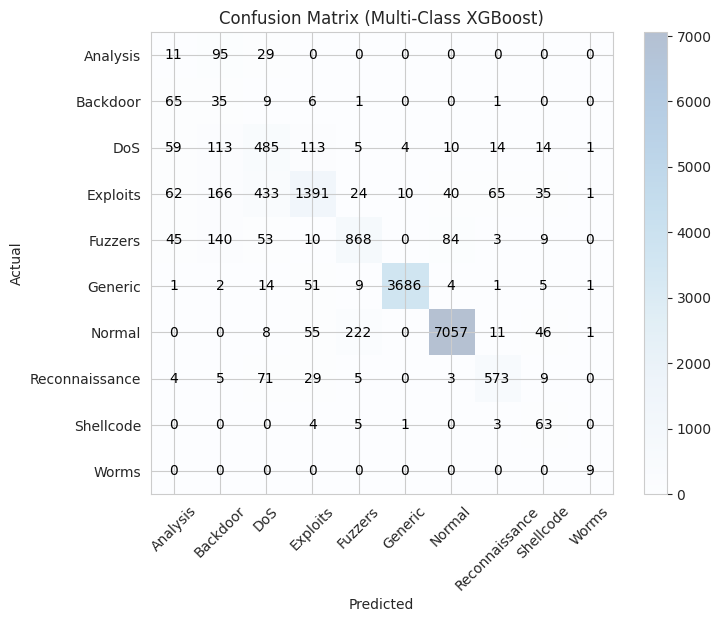

In [185]:
cm_multi = confusion_matrix(
    y_test_m,
    y_pred_m
)

labels = le_attack.classes_

plt.figure(figsize=(8,6))

plt.imshow(
    cm_multi,
    cmap="Blues",
    alpha=0.3
)

plt.title(
    "Confusion Matrix (Multi-Class XGBoost)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_multi.shape[0]):
    for j in range(cm_multi.shape[1]):
        plt.text(
            j,
            i,
            cm_multi[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.colorbar()

plt.show()

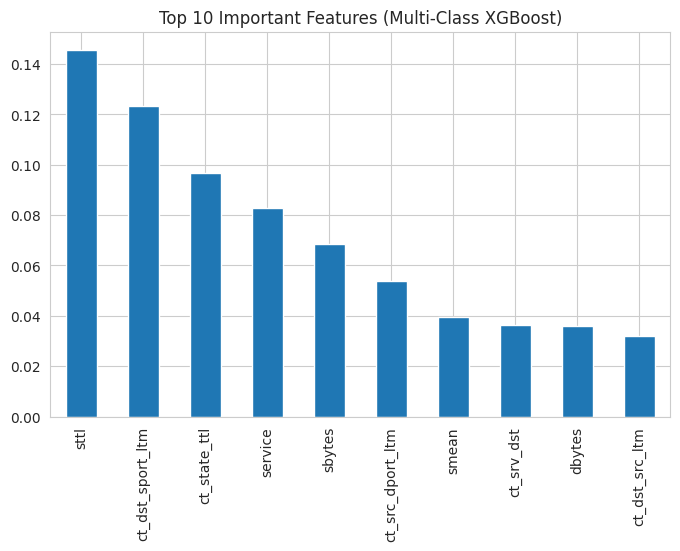

In [186]:
importance = model_multi.feature_importances_

feat_imp = pd.Series(
    importance,
    index=X_multi.columns
).sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

feat_imp.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Important Features (Multi-Class XGBoost)"
)

plt.show()

**RANDOM FOREST MODEL**

In [187]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [188]:
print("\n=== RANDOM FOREST (BINARY) ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, rf_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))



=== RANDOM FOREST (BINARY) ===
Accuracy: 95.36 %
F1 Score: 0.9574

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7400
           1       0.97      0.95      0.96      9067

    accuracy                           0.95     16467
   macro avg       0.95      0.95      0.95     16467
weighted avg       0.95      0.95      0.95     16467



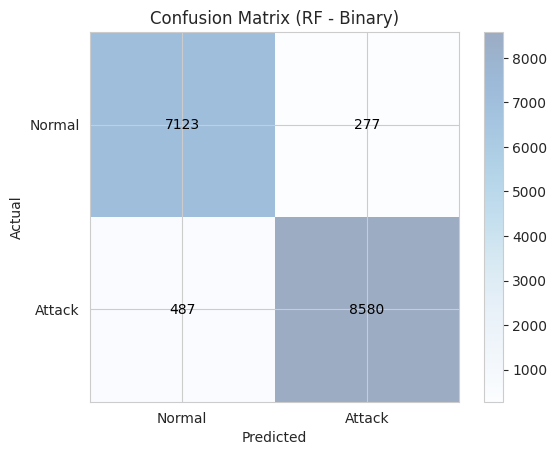

In [189]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure()
plt.imshow(cm_rf, cmap='Blues', alpha=0.4)

plt.title("Confusion Matrix (RF - Binary)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha='center', va='center', color='black')

plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])

plt.colorbar()
plt.show()

**Feature Importance (Random Forest)**

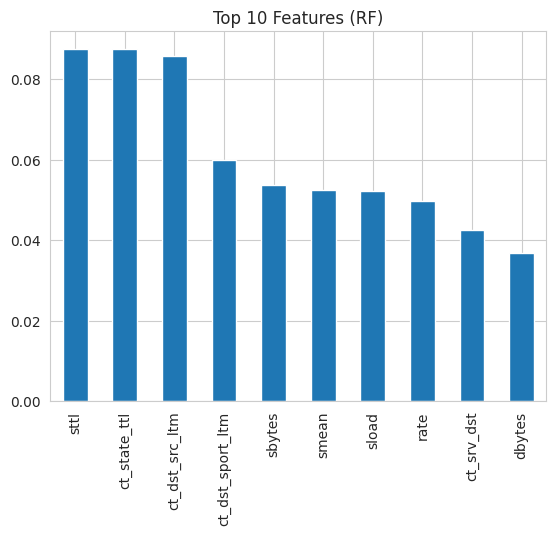

In [190]:
rf_importance = rf_model.feature_importances_
features = X.columns

rf_feat_imp = pd.Series(rf_importance, index=features).sort_values(ascending=False)

rf_feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Features (RF)")
plt.show()

**RANDOM FOREST — MULTI-CLASS (ATTACK TYPE)**

In [191]:
rf_model_multi = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model_multi.fit(
    X_train_m,
    y_train_m,
    sample_weight=sample_weights
)

rf_pred_m = rf_model_multi.predict(
    X_test_m
)



In [192]:
print("\n=== RANDOM FOREST (MULTI-CLASS) ===")
print("Accuracy:", round(accuracy_score(y_test_m, rf_pred_m) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test_m, rf_pred_m, average="weighted"), 4))

print("\nClassification Report:\n")
print(classification_report(y_test_m, rf_pred_m, zero_division=0))


=== RANDOM FOREST (MULTI-CLASS) ===
Accuracy: 79.93 %
F1 Score: 0.8237

Classification Report:

              precision    recall  f1-score   support

           0       0.14      0.10      0.11       135
           1       0.13      0.65      0.21       117
           2       0.44      0.63      0.52       818
           3       0.83      0.57      0.67      2227
           4       0.45      0.72      0.56      1212
           5       1.00      0.96      0.98      3774
           6       0.99      0.83      0.90      7400
           7       0.71      0.85      0.77       699
           8       0.16      0.83      0.27        76
           9       0.09      0.67      0.16         9

    accuracy                           0.80     16467
   macro avg       0.49      0.68      0.51     16467
weighted avg       0.87      0.80      0.82     16467



**LOGISTIC REGRESSION — BINARY CLASSIFICATION**

In [193]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [194]:
print("\n=== LOGISTIC REGRESSION (BINARY) ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, lr_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))


=== LOGISTIC REGRESSION (BINARY) ===
Accuracy: 90.06 %
F1 Score: 0.9105

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      7400
           1       0.90      0.92      0.91      9067

    accuracy                           0.90     16467
   macro avg       0.90      0.90      0.90     16467
weighted avg       0.90      0.90      0.90     16467



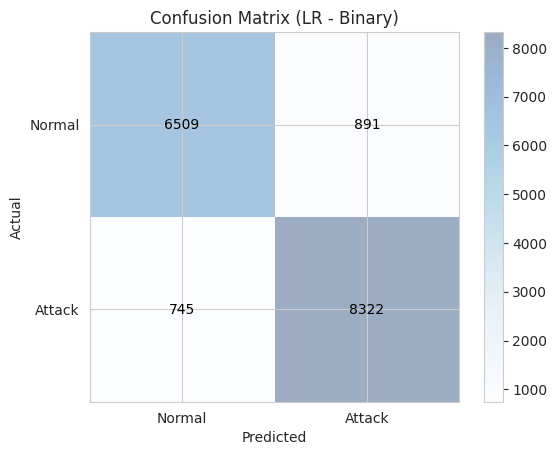

In [195]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure()
plt.imshow(cm_lr, cmap='Blues', alpha=0.4)

plt.title("Confusion Matrix (LR - Binary)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha='center', va='center', color='black')

plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])

plt.colorbar()
plt.show()

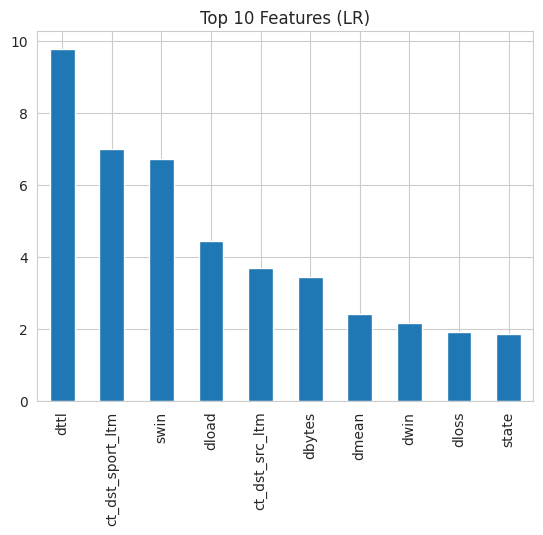

In [196]:
lr_importance = abs(lr_model.coef_[0])
features = X.columns

lr_feat_imp = pd.Series(lr_importance, index=features).sort_values(ascending=False)

lr_feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Features (LR)")
plt.show()

**LOGISTIC REGRESSION — MULTI-CLASS**

In [197]:
lr_model_multi = LogisticRegression(max_iter=1000)

lr_model_multi.fit(
    X_train_m,
    y_train_m,
    sample_weight=sample_weights
)

lr_pred_m = lr_model_multi.predict(
    X_test_m
)

In [198]:
print("\n=== LOGISTIC REGRESSION (MULTI-CLASS) ===")
print("Accuracy:", round(accuracy_score(y_test_m, lr_pred_m) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test_m, lr_pred_m, average="weighted"), 4))

print("\nClassification Report:\n")
print(classification_report(y_test_m, lr_pred_m, zero_division=0))


=== LOGISTIC REGRESSION (MULTI-CLASS) ===
Accuracy: 67.13 %
F1 Score: 0.722

Classification Report:

              precision    recall  f1-score   support

           0       0.12      0.22      0.16       135
           1       0.12      0.56      0.20       117
           2       0.41      0.48      0.44       818
           3       0.69      0.48      0.56      2227
           4       0.34      0.56      0.43      1212
           5       0.99      0.96      0.97      3774
           6       0.98      0.66      0.79      7400
           7       0.21      0.34      0.26       699
           8       0.06      0.76      0.11        76
           9       0.02      1.00      0.04         9

    accuracy                           0.67     16467
   macro avg       0.39      0.60      0.40     16467
weighted avg       0.82      0.67      0.72     16467



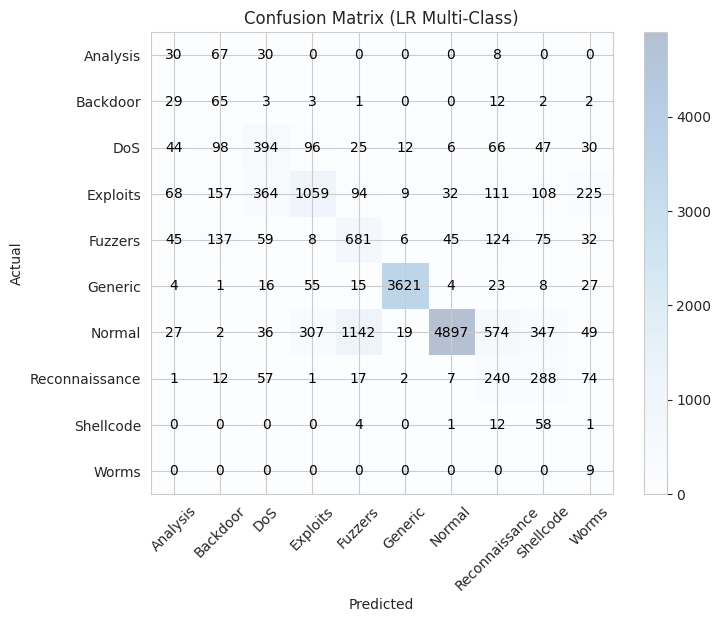

In [199]:
cm_lr_m = confusion_matrix(y_test_m, lr_pred_m)

plt.figure(figsize=(8,6))
plt.imshow(cm_lr_m, cmap='Blues', alpha=0.3)

plt.title("Confusion Matrix (LR Multi-Class)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_lr_m.shape[0]):
    for j in range(cm_lr_m.shape[1]):
        plt.text(j, i, cm_lr_m[i, j], ha='center', va='center', color='black')

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.colorbar()
plt.show()

In [200]:
models = ['XGBoost', 'Random Forest', 'Logistic Regression']

accuracy_list = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, lr_pred)
]

f1_list = [
    f1_score(y_test, y_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, lr_pred)
]

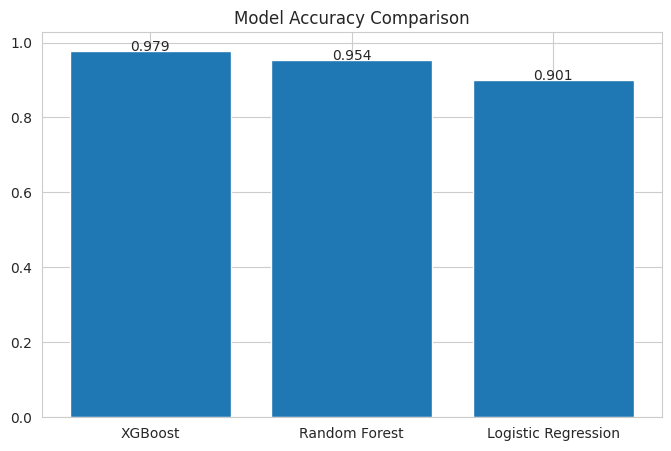

In [201]:
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy_list)

plt.title("Model Accuracy Comparison")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height(), 3),
             ha='center')

plt.show()

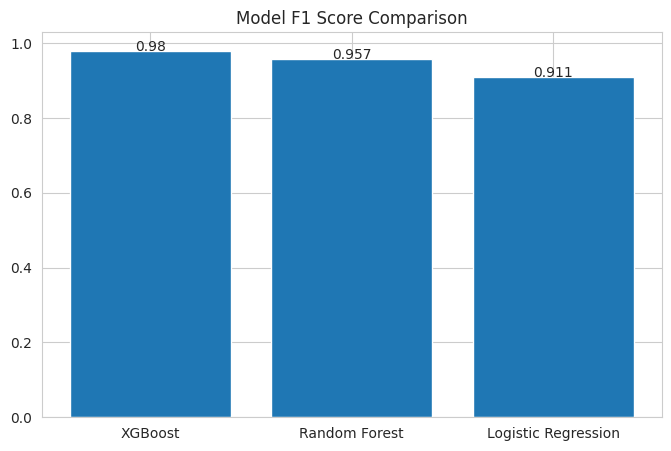

In [202]:
plt.figure(figsize=(8,5))
bars = plt.bar(models, f1_list)

plt.title("Model F1 Score Comparison")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height(), 3),
             ha='center')

plt.show()

In [203]:
# XGBoost
y_prob_xgb = model.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Logistic Regression
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [204]:
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

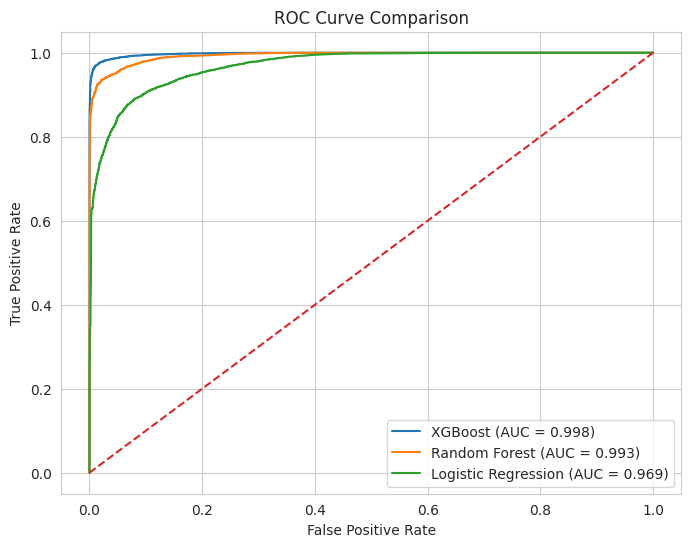

In [205]:
plt.figure(figsize=(8,6))

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [206]:
print("XGBoost AUC:", round(auc_xgb, 4))
print("Random Forest AUC:", round(auc_rf, 4))
print("Logistic Regression AUC:", round(auc_lr, 4))

XGBoost AUC: 0.9978
Random Forest AUC: 0.9932
Logistic Regression AUC: 0.9692


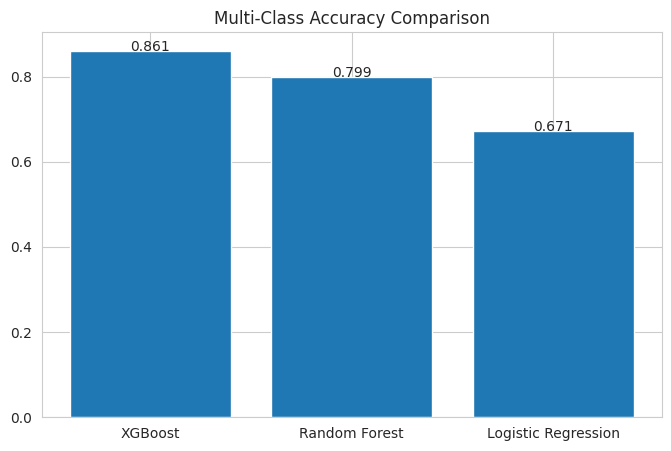

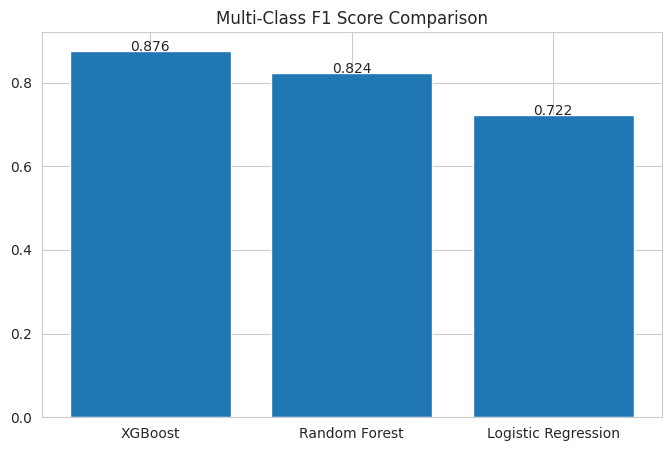

In [207]:
models = ['XGBoost', 'Random Forest', 'Logistic Regression']

accuracy_multi = [
    accuracy_score(y_test_m, y_pred_m),
    accuracy_score(y_test_m, rf_pred_m),
    accuracy_score(y_test_m, lr_pred_m)
]

f1_multi = [
    f1_score(y_test_m, y_pred_m, average="weighted"),
    f1_score(y_test_m, rf_pred_m, average="weighted"),
    f1_score(y_test_m, lr_pred_m, average="weighted")
]

# Accuracy plot
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy_multi)
plt.title("Multi-Class Accuracy Comparison")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height(), 3),
             ha='center')

plt.show()

# F1 plot
plt.figure(figsize=(8,5))
bars = plt.bar(models, f1_multi)
plt.title("Multi-Class F1 Score Comparison")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height(), 3),
             ha='center')

plt.show()

In [208]:


# Convert labels to binary format
classes = np.unique(y_test_m)
y_test_bin = label_binarize(y_test_m, classes=classes)

# Probabilities
y_prob_xgb_m = model_multi.predict_proba(X_test_m)
y_prob_rf_m = rf_model_multi.predict_proba(X_test_m)
y_prob_lr_m = lr_model_multi.predict_proba(X_test_m)

# Compute ROC AUC (macro)
from sklearn.metrics import roc_auc_score

auc_xgb_m = roc_auc_score(y_test_bin, y_prob_xgb_m, average="macro", multi_class="ovr")
auc_rf_m = roc_auc_score(y_test_bin, y_prob_rf_m, average="macro", multi_class="ovr")
auc_lr_m = roc_auc_score(y_test_bin, y_prob_lr_m, average="macro", multi_class="ovr")

print("XGBoost Multi AUC:", round(auc_xgb_m, 4))
print("Random Forest Multi AUC:", round(auc_rf_m, 4))
print("Logistic Regression Multi AUC:", round(auc_lr_m, 4))

XGBoost Multi AUC: 0.9776
Random Forest Multi AUC: 0.9719
Logistic Regression Multi AUC: 0.9424


**ROC CURVE FOR XG BOOST OF MULTI CLASSIFICATION**

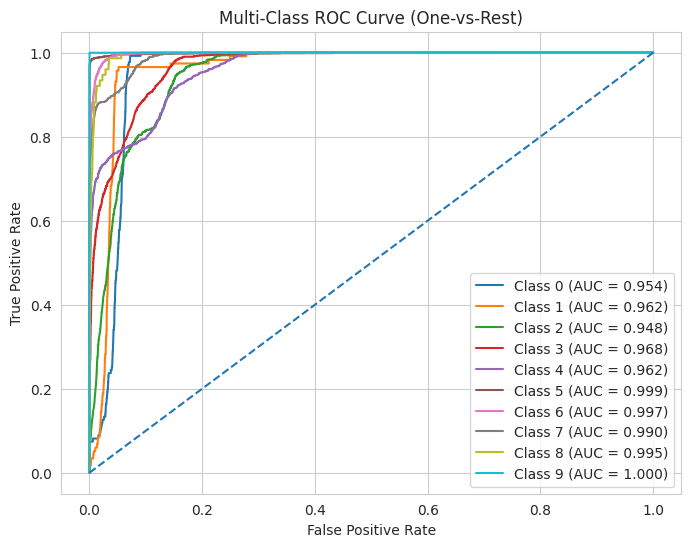

In [209]:
classes = np.unique(y_test_m)
y_test_bin = label_binarize(y_test_m, classes=classes)
n_classes = y_test_bin.shape[1]
y_prob = model_multi.predict_proba(X_test_m)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.3f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")

plt.legend()
plt.show()


**MODEL BUILDING USING TOP 10 FEATURES USING XGBOOST FOR BINARY CLASSIFICATION**

Top 10 Features:

['sttl', 'ct_state_ttl', 'ct_dst_sport_ltm', 'swin', 'ct_dst_src_ltm', 'proto', 'dbytes', 'tcprtt', 'is_sm_ips_ports', 'service']

=== XGBOOST TOP 10 FEATURES RESULTS ===
Accuracy: 94.47 %
F1 Score: 0.9496

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7418
           1       0.95      0.95      0.95      9049

    accuracy                           0.94     16467
   macro avg       0.94      0.94      0.94     16467
weighted avg       0.94      0.94      0.94     16467



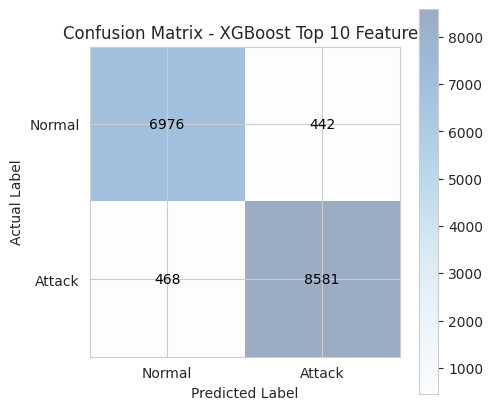

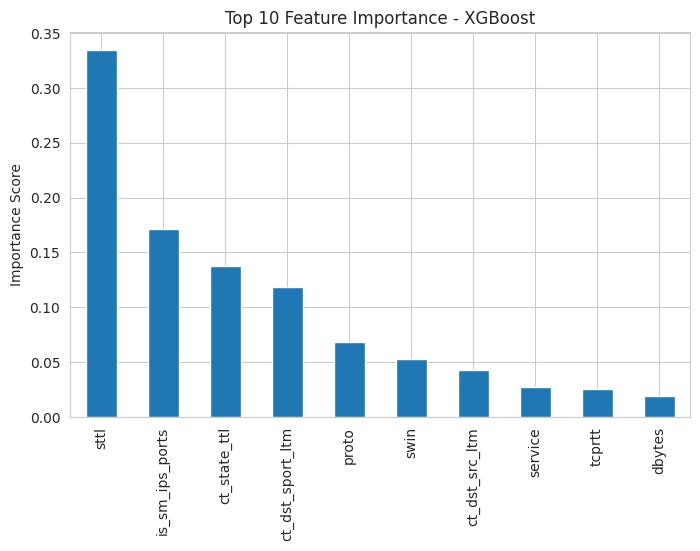

In [210]:
# ==============================
# TOP 10 FEATURE SELECTION
# ==============================

# Get feature importance from current XGBoost model
xgb_importance = model.feature_importances_

# Feature names
xgb_feature_names = X.columns

# Create sorted feature importance dataframe
xgb_feat_imp = pd.Series(
    xgb_importance,
    index=xgb_feature_names
).sort_values(ascending=False)

# Select Top 10 Features
top10_xgb_features = xgb_feat_imp.head(10).index.tolist()

print("Top 10 Features:\n")
print(top10_xgb_features)


# ==============================
# CREATE NEW DATASET WITH TOP 10 FEATURES
# ==============================

X_top10_xgb = X[top10_xgb_features]


# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train_top10, X_test_top10, y_train_top10, y_test_top10 = train_test_split(
    X_top10_xgb,
    y,
    test_size=0.2,
    random_state=42
)


# ==============================
# BUILD XGBOOST MODEL
# ==============================

xgb_top10_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

xgb_top10_model.fit(X_train_top10, y_train_top10)


# ==============================
# PREDICTIONS
# ==============================

y_pred_top10 = xgb_top10_model.predict(X_test_top10)


# ==============================
# PERFORMANCE METRICS
# ==============================

print("\n=== XGBOOST TOP 10 FEATURES RESULTS ===")

print(
    "Accuracy:",
    round(accuracy_score(y_test_top10, y_pred_top10) * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(f1_score(y_test_top10, y_pred_top10), 4)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_top10,
        y_pred_top10
    )
)


# ==============================
# CONFUSION MATRIX
# ==============================

cm_top10_xgb = confusion_matrix(
    y_test_top10,
    y_pred_top10
)

plt.figure(figsize=(5,5))

plt.imshow(
    cm_top10_xgb,
    cmap='Blues',
    alpha=0.4
)

plt.title("Confusion Matrix - XGBoost Top 10 Features")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add values inside matrix
for i in range(cm_top10_xgb.shape[0]):
    for j in range(cm_top10_xgb.shape[1]):
        plt.text(
            j,
            i,
            cm_top10_xgb[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.xticks([0,1], ["Normal", "Attack"])
plt.yticks([0,1], ["Normal", "Attack"])

plt.colorbar()

plt.show()


# ==============================
# TOP 10 FEATURE IMPORTANCE PLOT
# ==============================

xgb_top10_importance = xgb_top10_model.feature_importances_

xgb_top10_feat_imp = pd.Series(
    xgb_top10_importance,
    index=top10_xgb_features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

xgb_top10_feat_imp.plot(kind='bar')

plt.title("Top 10 Feature Importance - XGBoost")

plt.ylabel("Importance Score")

plt.show()

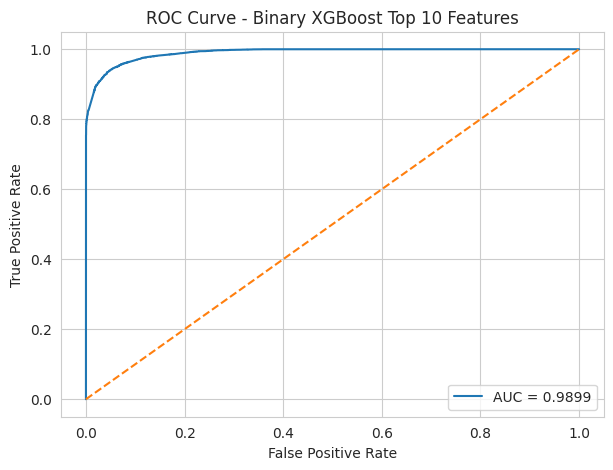

In [218]:
# ==========================================================
# ROC CURVE - BINARY XGBOOST TOP 10 FEATURES MODEL
# ==========================================================

from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_prob_binary_top10 = xgb_top10_model.predict_proba(X_test_top10)[:, 1]

# ROC values
fpr_binary_top10, tpr_binary_top10, _ = roc_curve(
    y_test_top10,
    y_prob_binary_top10
)

# AUC score
roc_auc_binary_top10 = auc(
    fpr_binary_top10,
    tpr_binary_top10
)

# Plot
plt.figure(figsize=(7,5))

plt.plot(
    fpr_binary_top10,
    tpr_binary_top10,
    label=f"AUC = {roc_auc_binary_top10:.4f}"
)

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Binary XGBoost Top 10 Features")

plt.legend()

plt.show()

In [219]:
# ============================================
# TOP 10 FEATURE SELECTION - MULTI CLASS XGB
# ============================================

xgb_multi_importance = model_multi.feature_importances_

xgb_multi_feature_names = X_multi.columns

xgb_multi_feat_imp = pd.Series(
    xgb_multi_importance,
    index=xgb_multi_feature_names
).sort_values(ascending=False)

top10_multi_xgb_features = xgb_multi_feat_imp.head(10).index.tolist()

print("Top 10 Features (Multi-Class):\n")
print(top10_multi_xgb_features)


# ============================================
# CREATE TOP 10 DATASET
# ============================================

X_multi_top10 = X_multi[top10_multi_xgb_features]


# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train_multi_top10, X_test_multi_top10, y_train_multi_top10, y_test_multi_top10 = train_test_split(
    X_multi_top10,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)


# ============================================
# SCALING
# ============================================

scaler_multi_top10 = StandardScaler()

X_train_multi_top10 = scaler_multi_top10.fit_transform(
    X_train_multi_top10
)

X_test_multi_top10 = scaler_multi_top10.transform(
    X_test_multi_top10
)


# ============================================
# CLASS WEIGHTS
# ============================================

from sklearn.utils.class_weight import compute_sample_weight

sample_weights_top10 = compute_sample_weight(
    class_weight="balanced",
    y=y_train_multi_top10
)


# ============================================
# BUILD MULTI-CLASS XGBOOST MODEL
# ============================================

xgb_multi_top10_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    eval_metric="mlogloss",
    random_state=42
)


# ============================================
# TRAIN MODEL
# ============================================

xgb_multi_top10_model.fit(
    X_train_multi_top10,
    y_train_multi_top10,
    sample_weight=sample_weights_top10
)


# ============================================
# PREDICTIONS
# ============================================

y_pred_multi_top10 = xgb_multi_top10_model.predict(
    X_test_multi_top10
)


# ============================================
# PERFORMANCE METRICS
# ============================================

print("\n=== MULTI-CLASS TOP 10 FEATURES RESULTS ===")

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test_multi_top10,
            y_pred_multi_top10
        ) * 100,
        2
    ),
    "%"
)

print(
    "Weighted F1:",
    round(
        f1_score(
            y_test_multi_top10,
            y_pred_multi_top10,
            average="weighted"
        ),
        4
    )
)

print(
    "Macro F1:",
    round(
        f1_score(
            y_test_multi_top10,
            y_pred_multi_top10,
            average="macro"
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_multi_top10,
        y_pred_multi_top10,
        zero_division=0
    )
)

Top 10 Features (Multi-Class):

['sttl', 'ct_dst_sport_ltm', 'ct_state_ttl', 'service', 'sbytes', 'ct_src_dport_ltm', 'smean', 'ct_srv_dst', 'dbytes', 'ct_dst_src_ltm']

=== MULTI-CLASS TOP 10 FEATURES RESULTS ===
Accuracy: 85.04 %
Weighted F1: 0.8649
Macro F1: 0.6131

Classification Report:

              precision    recall  f1-score   support

           0       0.10      0.16      0.12       135
           1       0.13      0.56      0.21       117
           2       0.44      0.68      0.53       818
           3       0.84      0.58      0.69      2227
           4       0.68      0.70      0.69      1212
           5       1.00      0.97      0.99      3774
           6       0.98      0.93      0.95      7400
           7       0.83      0.85      0.84       699
           8       0.26      0.83      0.39        76
           9       0.56      1.00      0.72         9

    accuracy                           0.85     16467
   macro avg       0.58      0.73      0.61     16467
we

In [220]:


macro_auc_top10 = roc_auc_score(
    y_test_multi_bin_top10,
    y_prob_multi_top10,
    average="macro",
    multi_class="ovr"
)

print(
    "Macro ROC-AUC:",
    round(macro_auc_top10, 4)
)

Macro ROC-AUC: 0.9821


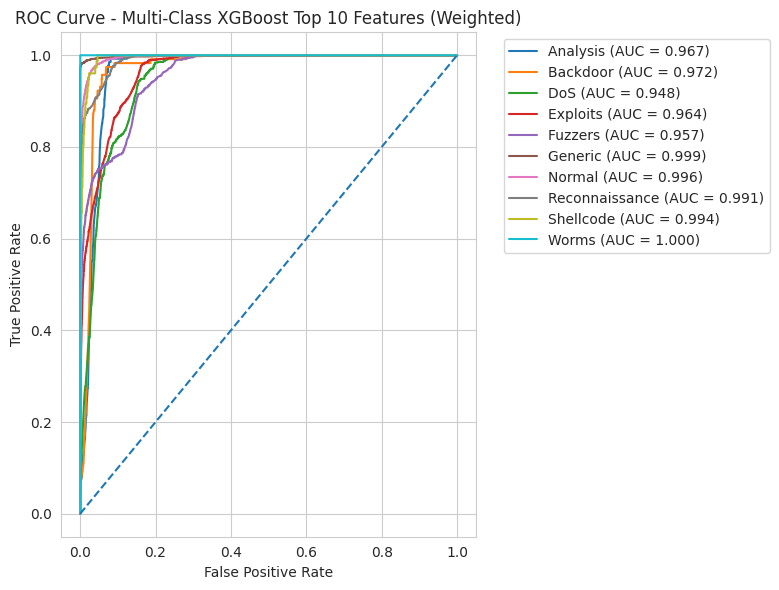

In [222]:
# ==========================================================
# ROC CURVE - MULTI-CLASS XGBOOST TOP 10 FEATURES (WEIGHTED)
# ==========================================================



# Classes
multi_classes_top10 = np.unique(y_test_multi_top10)

# Binarize labels
y_test_multi_bin_top10 = label_binarize(
    y_test_multi_top10,
    classes=multi_classes_top10
)

# Number of classes
n_classes_top10 = y_test_multi_bin_top10.shape[1]

# Predicted probabilities
y_prob_multi_top10 = xgb_multi_top10_model.predict_proba(
    X_test_multi_top10
)

# ROC dictionaries
fpr_multi_top10 = {}
tpr_multi_top10 = {}
roc_auc_multi_top10 = {}

# ROC for each class
for i in range(n_classes_top10):

    fpr_multi_top10[i], tpr_multi_top10[i], _ = roc_curve(
        y_test_multi_bin_top10[:, i],
        y_prob_multi_top10[:, i]
    )

    roc_auc_multi_top10[i] = auc(
        fpr_multi_top10[i],
        tpr_multi_top10[i]
    )

# Plot
plt.figure(figsize=(8,6))

for i in range(n_classes_top10):

    plt.plot(
        fpr_multi_top10[i],
        tpr_multi_top10[i],
        label=f"{le_attack.classes_[i]} (AUC = {roc_auc_multi_top10[i]:.3f})"
    )

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Multi-Class XGBoost Top 10 Features (Weighted)"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [214]:


# Binary model
joblib.dump(model, "/content/models/xgb_binary.pkl")

# Multiclass model
joblib.dump(model_multi, "/content/models/xgb_multi.pkl")



# Attack category encoder
joblib.dump(le_attack, "/content/models/attack_encoder.pkl")

#encoders save
joblib.dump(encoders, "/content/models/encoders.pkl")

print("All deployment artifacts saved!")

All deployment artifacts saved!


In [216]:
# Scaler
joblib.dump(scaler, "/content/models/binary_scaler.pkl")
joblib.dump(multiclass_scaler, "/content/models/multiclass_scaler.pkl")

['/content/models/multiclass_scaler.pkl']

# Conclusion

This project developed a real-time Intrusion Detection System (IDS) using the UNSW-NB15 dataset, machine learning models, Apache Kafka, and a cloud-based deployment architecture.

## Data Preprocessing

The UNSW-NB15 dataset was cleaned and prepared for machine learning by:

* Handling missing values and duplicate records.
* Encoding categorical features using Label Encoding.
* Scaling numerical features using StandardScaler.
* Creating two prediction tasks:

  * Binary Classification (Normal vs Attack)
  * Multi-Class Classification (Attack Category Identification)

---

## Binary Classification Experiments

Several machine learning models were evaluated for binary intrusion detection:

* XGBoost Classifier
* Random Forest Classifier
* Logistic Regression

Performance was evaluated using:

* Accuracy
* F1 Score
* Classification Report
* Confusion Matrix
* ROC-AUC Curve

Feature importance analysis was performed using XGBoost, and a Top-10 Feature model was also trained to evaluate whether dimensionality reduction could maintain predictive performance.

Results showed that XGBoost achieved the best overall performance and was selected for deployment.

---

## Multi-Class Classification Experiments

The attack category prediction task was significantly more challenging due to severe class imbalance within the dataset.

The following approaches were explored:

### 1. Baseline XGBoost Multi-Class Model

A multi-class XGBoost classifier was trained using all available features.

Evaluation metrics included:

* Accuracy
* Weighted F1 Score
* Macro F1 Score
* ROC-AUC
* Confusion Matrix

The baseline model achieved strong overall accuracy but showed lower performance on minority attack classes.

---

### 2. SMOTE + Tomek Links

To address class imbalance, SMOTE-Tomek resampling was applied to generate synthetic minority class samples and remove noisy boundaries.

However, experimental results showed:

* Reduced Accuracy
* Reduced Weighted F1 Score
* Reduced Macro F1 Score

Therefore, SMOTE-Tomek was not selected for the final model.

---

### 3. Class-Weighted XGBoost

A class-weighted XGBoost model was then trained using balanced sample weights.

This approach:

* Improved minority class detection.
* Increased Macro F1 Score from approximately 0.60 to 0.62.
* Significantly improved recall for rare attack categories.
* Maintained strong overall accuracy and weighted F1 performance.

Because intrusion detection requires identifying rare attack patterns, the class-weighted model was chosen as the final multi-class model.

---

### 4. Top-10 Feature Analysis

Feature importance scores from the trained XGBoost model were used to identify the most influential features.

A separate Top-10 Feature model was trained and evaluated to analyze:

* Feature reduction capability
* Model efficiency
* Performance trade-offs

The comparison demonstrated the effectiveness of the selected features while validating the importance ranking generated by XGBoost.

---

## Final Model Selection

The final deployment architecture uses:

### Binary Intrusion Detection

* XGBoost Binary Classifier
* Binary Scaler
* Predicts:

  * Normal Traffic
  * Attack Traffic

### Multi-Class Attack Classification

* Class-Weighted XGBoost Classifier
* Multi-Class Scaler
* Predicts attack categories such as:

  * Analysis
  * Backdoor
  * DoS
  * Exploits
  * Fuzzers
  * Generic
  * Reconnaissance
  * Shellcode
  * Worms

---

## Deployment Readiness

The trained models and preprocessing artifacts were exported using Joblib:

* xgb_binary.pkl
* xgb_multi.pkl
* binary_scaler.pkl
* multiclass_scaler.pkl
* encoders.pkl
* attack_encoder.pkl

These artifacts are integrated into a Kafka-based real-time inference pipeline, where incoming network traffic is analyzed, classified, and visualized through a dashboard deployed on AWS.
